In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import equinox as eqx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from diffrax import diffeqsolve, ODETerm, SaveAt, Tsit5, PIDController, Dopri5,Kvaerno5
import os

## Acreció usando la aproximación de Kerr durante la dominancia de radiación


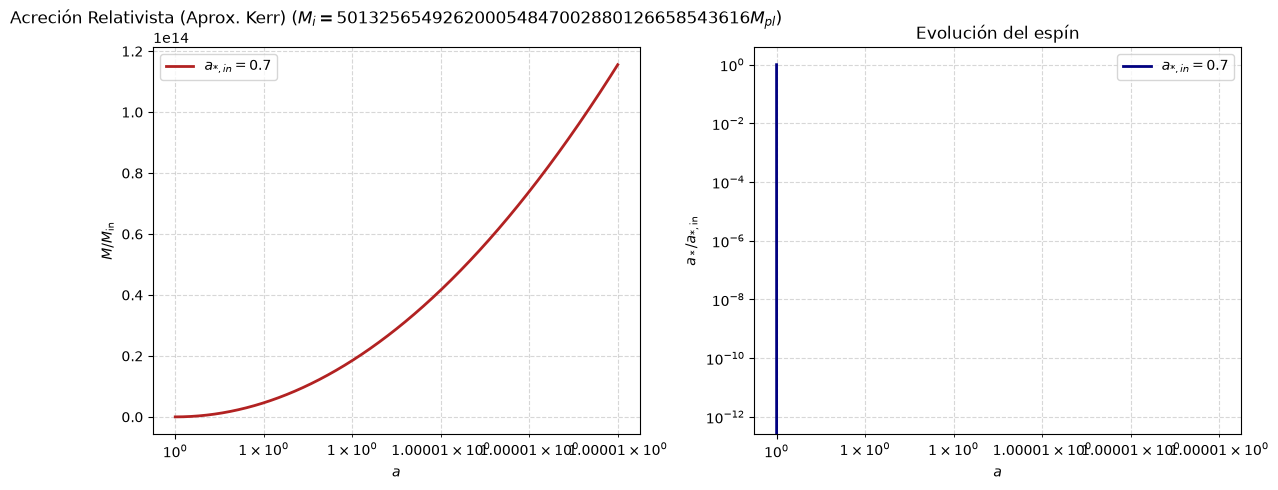

In [55]:
G = 1.0
c = 1.0
Mp = 1.0 / np.sqrt(8.0 * np.pi * G)

# Parámetros cosmológicos y de evaporación
alpha_evap = 1.0 / (15.0 * 256.0 * np.pi)
omega_r = 8.4e-5
w = 1.0 / 3.0
H_0 = 1.18e-61  # En unidades de Planck
rho_c = (3.0 * H_0**2) / (8.0 * np.pi * G)
rho_0 = omega_r * rho_c
gamma_spin = 1e-4

def C4(M, rho_inf_val, a_star):
    """
    Aproximación de acreción de Kerr.
    En unidades naturales, la corrección de Kerr depende directamente de a_star.
    """
    r_plus = M * (1.0 + np.sqrt(1.0 - a_star**2.0))
    u_c = M / (2.0 * r_plus)
    rho_h = 3.0 * M / (4.0 * np.pi * r_plus**3.0)
    
    return u_c * (rho_h / rho_inf_val)**(1.0 / (1.0 + w))

def crecimiento(a, y, M_inicial):
    """Campo vectorial usando el factor de escala absoluto 'a'."""
    M, a_star = y
    
    # Restricciones numéricas para evitar colapsos
    M_safe = np.maximum(M, M_inicial * 1e-4)
    a_star = np.clip(a_star, 0.0, 0.9999)
    
    # Evolución de la densidad de radiación
    rho_val = rho_0 * a**(-4.0)
    
    C_4 = C4(M_safe, rho_val, a_star)
    r_plus = M_safe * (1.0 + np.sqrt(1.0 - a_star**2.0))
    
    tasa_acrecion = 4.0 * np.pi * C_4 * (r_plus**2.0) * rho_val * (1.0 + w)
    tasa_evaporacion = - alpha_evap / (M_safe**2.0)
    
    dM_dt = tasa_acrecion + tasa_evaporacion
    da_star_dt = - (2.0 * a_star / M_safe) * dM_dt - a_star * (8.0 * np.pi * gamma_spin) * (Mp**4) / (M_safe**3)
    

    dt_da = a / (H_0 * np.sqrt(omega_r))
    
    dM_da = dM_dt * dt_da
    da_star_da = da_star_dt * dt_da
    
    return [dM_da, da_star_da]

def crear_evento_evaporacion(M_inicial):
    def evento_evaporacion(a, y, M_inicial):
        return y[0] - (M_inicial * 1e-2)
    evento_evaporacion.terminal = True
    evento_evaporacion.direction = -1
    return evento_evaporacion

M_inicial = 1e38 
a_star_inicial = 0.7
a_ini = 1
a_fin = a_ini + 1e-5

a_eval = np.logspace(np.log10(a_ini), np.log10(a_fin), 50000)

solucion = solve_ivp(
    fun=crecimiento,
    t_span=(a_ini, a_fin),
    y0=[M_inicial, a_star_inicial],
    args=(M_inicial,),
    t_eval=a_eval,
    method='Radau',     
    events=crear_evento_evaporacion(M_inicial),
    rtol=1e-7,
    atol=1e-7,
    first_step=a_ini * 1e-30
)


if not solucion.success and solucion.status != 1:
    print(f"La integración falló: {solucion.message}")
else:
    a_valido = solucion.t
    M_evolucion = solucion.y[0]
    a_star_evolucion = solucion.y[1]
    
    M_relativo = M_evolucion / M_inicial
    a_star_relativo = a_star_evolucion / a_star_inicial

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(a_valido, M_relativo, color='firebrick', lw=2, label=rf'$a_{{*,in}} = {a_star_inicial}$')
    ax1.set_xscale('log')
    ax1.set_xlabel(r'$a$')
    ax1.set_ylabel(r'$M / M_{\mathrm{in}}$')
    ax1.set_title(rf'Acreción Relativista (Aprox. Kerr) ($M_i = {M_inicial/Mp:.0f} M_{{pl}}$)')
    ax1.grid(True, which='both', linestyle='--', alpha=0.5)
    ax1.legend()

    ax2.plot(a_valido, a_star_relativo, color='navy', lw=2, label=rf'$a_{{*,in}} = {a_star_inicial}$')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel(r'$a$')
    ax2.set_ylabel(r'$a_* / a_{*,\mathrm{in}}$')
    ax2.set_title('Evolución del espín')
    ax2.grid(True, which='both', linestyle='--', alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()

## Acreción y evaporación durante la dominancia de radiación basada en Kalita

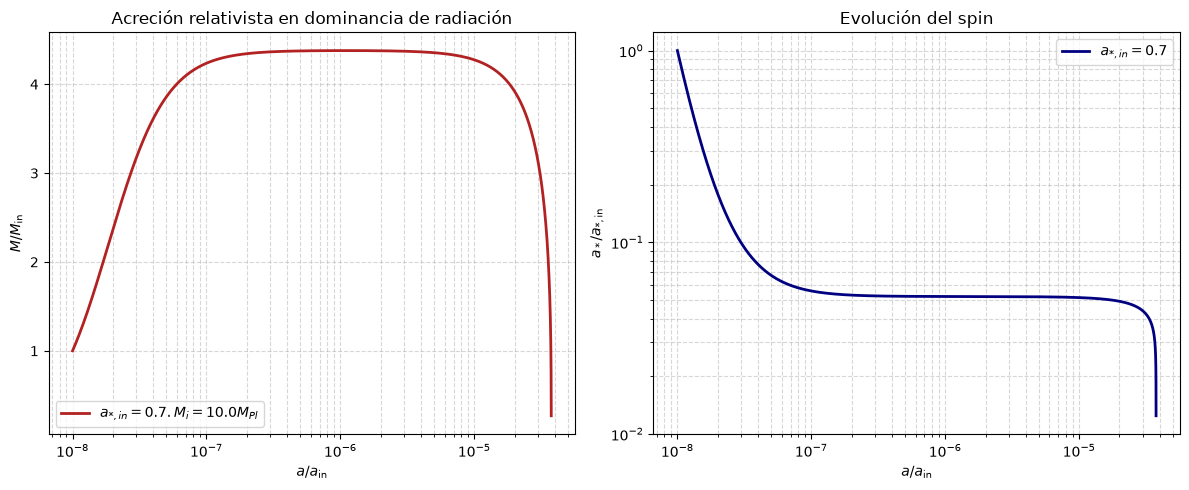

In [3]:

G = 1.0
Mp = 1.0 / np.sqrt(8.0 * np.pi * G) 

f = 0.2  # Fracción de la masa del horizonte 

def lambda_kerr(a_star):
    """Eficiencia de acreción relativista (Ec. 3.11)"""
    return - (a_star**2) * (0.255 * a_star + 0.645) + 10.389

def rho_inf(t):
    """Densidad de energía del fondo en era de radiación"""
    H = 1.0 / (2.0 * t)
    return 3.0 * (Mp**2) * (H**2)


def crecimiento(a, y):
    """
    Campo vectorial de evolución ajustado para masas altas.
    """
    M, a_star = y
    a_star = np.clip(a_star, 0.0, 0.9999)
    
    # Calcular el tiempo inicial real usando el factor f
    t_in = M_inicial / (8.0 * np.pi * f * (Mp**2))
    
    # Mapear el factor de escala al tiempo cósmico real
    t = t_in * (a / a_ini)**2 
    
    lam = lambda_kerr(a_star)
    epsilon = 1e-3  # Eficiencia de evaporación adimensional
    gamma_spin = 1e-4 # Eficiencia de disminución del spin adimensional    
    
    dM_acc = 4.0 * np.pi * lam * (G**2) * (M**2) * rho_inf(t)
    dM_evap = - epsilon * (Mp**4) / (M**2)
    dM_dt = dM_acc + dM_evap
    
    da_star_dt = - (2.0 * a_star / M) * dM_dt - a_star * (8.0 * np.pi * gamma_spin) * (Mp**4) / (M**3)
    
    # 3. Derivada dt/da usando el nuevo mapeo temporal
    dt_da = 2.0 * t_in * a / (a_ini**2)
    
    return [dM_dt * dt_da, da_star_dt * dt_da]

def evento_evaporacion(a, y):
    """
    Detiene la integración numéricamente cuando la masa cae al 1% de su valor inicial.
    Físicamente evita la rigidez extrema de M -> 0 sin perder precisión gráfica.
    """
    return y[0] - (M_inicial * 1e-1)

evento_evaporacion.terminal = True #Fin de la simulación cuando evento_evaporacion es 0
evento_evaporacion.direction = -1 #Se detiene solo si la tasa está disminuyendo 

# --- CONFIGURACIÓN DE LA SIMULACIÓN ---
M_inicial = 10  * Mp
a_star_inicial = 0.7
a_ini = 1e-8
a_fin = 1/3400.0 

# Vector de evaluación espaciado logarítmicamente para el factor de escala
a_eval = np.logspace(np.log10(a_ini), np.log10(a_fin), 50000)

# Resolución del sistemas de EDOs
solucion = solve_ivp(
    fun=crecimiento,
    t_span=(a_ini, a_fin),
    y0=[M_inicial, a_star_inicial],
    t_eval=a_eval,
    method='Radau',     
    events=evento_evaporacion,
    rtol=1e-7,
    atol=1e-7
)

if not solucion.success:
    print(f"La integración falló: {solucion.message}")
else:
    a_valido = solucion.t
    M_evolucion = solucion.y[0]
    a_star_evolucion = solucion.y[1]
    
    M_relativo = M_evolucion / M_inicial
    a_star_relativo = a_star_evolucion / a_star_inicial


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(a_valido, M_relativo, color='firebrick', lw=2, label=rf'$a_{{*,in}} = {a_star_inicial}. M_{{i}} = {M_inicial/Mp} M_{{Pl}}$')
ax1.set_xscale('log')
ax1.set_xlabel(r'$a / a_{\mathrm{in}}$')
ax1.set_ylabel(r'$M / M_{\mathrm{in}}$')
ax1.set_title('Acreción relativista en dominancia de radiación')
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.legend()

ax2.plot(a_valido, a_star_relativo, color='navy', lw=2, label=rf'$a_{{*,in}} = {a_star_inicial}$')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r'$a / a_{\mathrm{in}}$')
ax2.set_ylabel(r'$a_* / a_{*,\mathrm{in}}$')
ax2.set_title('Evolución del spin')
ax2.grid(True, which='both', linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

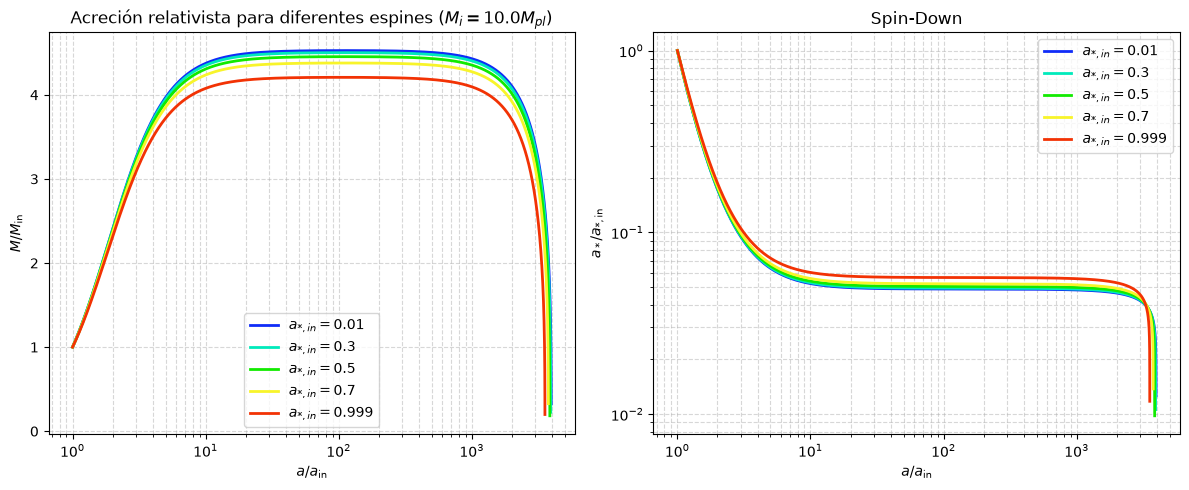

In [4]:

def crecimiento(a, y, M_inicial):
    """
    Campo vectorial de evolución.
    Pasamos M_inicial como argumento para calcular t_in dinámicamente.
    """
    M, a_star = y
    a_star = np.clip(a_star, 0.0, 0.99999)
    
    # Calcular el tiempo inicial real de formación
    t_in = M_inicial / (8.0 * np.pi * f * (Mp**2))
    
    # Mapear el factor de escala al tiempo cósmico real 
    t = t_in * (a / 1.0)**2 
    
    lam = lambda_kerr(a_star)
    epsilon = 1e-3  
    gamma_spin = 1e-4    
    
    # Derivadas temporales (d/dt)
    dM_acc = 4.0 * np.pi * lam * (G**2) * (M**2) * rho_inf(t)
    dM_evap = - epsilon * (Mp**4) / (M**2)
    dM_dt = dM_acc + dM_evap
    
    da_star_dt = - (2.0 * a_star / M) * dM_dt - a_star * (8.0 * np.pi * gamma_spin) * (Mp**4) / (M**3)
    
    # Derivada dt/da (dt/da = 2 * t_in * a)
    dt_da = 2.0 * t_in * a
    
    return [dM_dt * dt_da, da_star_dt * dt_da]

def crear_evento_evaporacion(M_inicial):
    """
    Crea una función de evento personalizada para cada M_inicial.
    """
    def evento(a, y, M_inicial):
        return y[0] - (M_inicial * 1e-1)
    evento.terminal = True
    evento.direction = -1
    return evento

M_inicial = 10.0 * Mp
a_ini = 1
a_fin = 10**8  


spines_iniciales = [0.01, 0.3 ,0.5, 0.7, 0.999]
colores = ['#0f2cf8','#00eabb', '#12ea00','#f8f42a', '#f23204']

a_eval = np.logspace(np.log10(a_ini), np.log10(a_fin), 50000)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for a_star_inicial, color in zip(spines_iniciales, colores):
    
    evento_evap = crear_evento_evaporacion(M_inicial)
    
    solucion = solve_ivp(
        fun=crecimiento,
        t_span=(a_ini, a_fin),
        y0=[M_inicial, a_star_inicial],
        args=(M_inicial,), 
        t_eval=a_eval,
        method='Radau',
        events=evento_evap,
        rtol=1e-7,
        atol=1e-7
    )
    if solucion.success:
        a_valido = solucion.t
        M_evolucion = solucion.y[0]
        a_star_evolucion = solucion.y[1]
        
        M_relativo = M_evolucion / M_inicial
        a_star_relativo = a_star_evolucion / a_star_inicial
        
        ax1.plot(
            a_valido, 
            M_relativo, 
            color=color, 
            lw=2, 
            label=rf'$a_{{*,in}} = {a_star_inicial}$'
        )
        
        ax2.plot(
            a_valido, 
            a_star_relativo, 
            color=color, 
            lw=2, 
            label=rf'$a_{{*,in}} = {a_star_inicial}$'
        )

ax1.set_xscale('log')
ax1.set_xlabel(r'$a / a_{\mathrm{in}}$')
ax1.set_ylabel(r'$M / M_{\mathrm{in}}$')
ax1.set_title(rf'Acreción relativista para diferentes espines ($M_i = {M_inicial/Mp} M_{{pl}}$)')
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.legend()


ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r'$a / a_{\mathrm{in}}$')
ax2.set_ylabel(r'$a_* / a_{*,\mathrm{in}}$')
ax2.set_title('Spin-Down')
ax2.grid(True, which='both', linestyle='--', alpha=0.5)
ax2.legend()
plt.savefig('Accretarraya.png')
plt.tight_layout()
plt.show()